https://gymnasium.farama.org/environments/box2d/lunar_lander/#action-space

In [11]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
import matplotlib.pyplot as plt


## Espacio de Acciones

| Acción | Descripción                     |
| -----: | ------------------------------- |
|    `0` | No hacer nada                   |
|    `1` | Activar motor lateral izquierdo |
|    `2` | Activar motor principal         |
|    `3` | Activar motor lateral derecho   |


## Espacio de Estados

| Índice | Variable                  | Descripción                                              | Rango aproximado |
|--------:|---------------------------|----------------------------------------------------------|------------------|
| 0       | `x`                       | Posición horizontal del lander                          | `[-2.5, 2.5]`    |
| 1       | `y`                       | Posición vertical del lander                            | `[-2.5, 2.5]`    |
| 2       | `v_x`                     | Velocidad lineal horizontal                             | `[-10, 10]`      |
| 3       | `v_y`                     | Velocidad lineal vertical                               | `[-10, 10]`      |
| 4       | `θ`                       | Ángulo de inclinación del lander                        | `[-π·2, π·2]`    |
| 5       | `ω`                       | Velocidad angular                                       | `[-10, 10]`      |
| 6       | `leg_left_contact`        | Contacto de la pierna izquierda con el suelo (`0/1`)    | `[0, 1]`         |
| 7       | `leg_right_contact`       | Contacto de la pierna derecha con el suelo (`0/1`)      | `[0, 1]`         |

### Forma del espacio de estados

```python
Box(
    low=[ -2.5, -2.5, -10., -10., -6.2831855, -10., -0., -0. ],
    high=[ 2.5,  2.5,  10.,  10.,  6.2831855,  10.,  1.,  1. ],
    shape=(8,),
    dtype=float32
)

## 1. Entrenamiento

In [12]:
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.rewards.append(info["episode"]["r"])
        return True


# Entorno de entrenamiento y evaluación separados
train_env = Monitor(gym.make("LunarLander-v3"))
eval_env = Monitor(gym.make("LunarLander-v3"))

model = A2C("MlpPolicy", train_env, verbose=1, learning_rate=7e-4, ent_coef=0.01)

# EvalCallback evalúa cada N pasos y guarda el mejor automáticamente
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./best_model/",  # guarda aquí el mejor
    log_path="./logs/",
    eval_freq=5_000,          # evalúa cada 5k pasos
    n_eval_episodes=10,       # promedia sobre 10 episodios
    deterministic=True,
    render=False,
    verbose=1,
)

reward_callback = RewardCallback()

from stable_baselines3.common.callbacks import CallbackList
callbacks = CallbackList([eval_callback, reward_callback])

model.learn(total_timesteps=250000, callback=callbacks)

model.save("lunarlander_a2c_final")
train_env.close()
eval_env.close()

print("Entrenamiento completado")

# Cargar el MEJOR modelo
best_model = A2C.load("./best_model/best_model")

Using cpu device
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 97.5     |
|    ep_rew_mean        | -268     |
| time/                 |          |
|    fps                | 1514     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.952   |
|    explained_variance | -0.00397 |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -5.16    |
|    value_loss         | 110      |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 119      |
|    ep_rew_mean        | -344     |
| time/                 |          |
|    fps                | 1520     |
|    iterations         | 200      |
|    time_elapsed       | 0        |
|    total_timesteps   

## 2. Métricas de entrenamiento

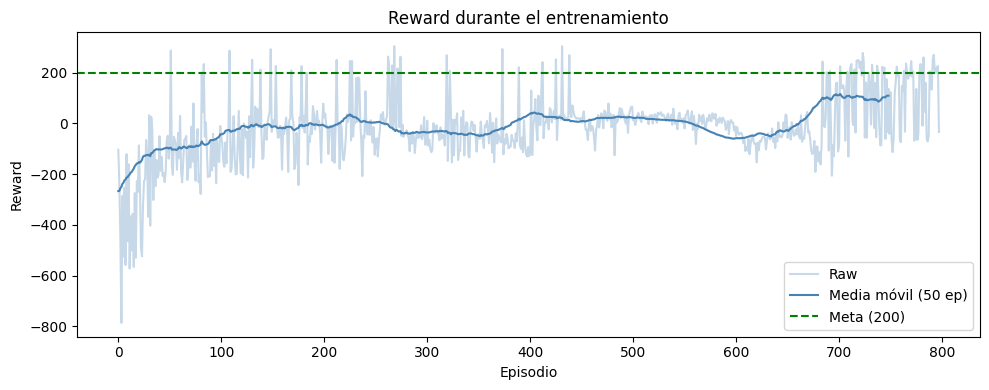

Episodios totales : 798
Reward final (media últimos 50): 109.5


In [13]:

# Suavizado con media móvil
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(cb.rewards, alpha=0.3, color='steelblue', label='Raw')
if len(cb.rewards) >= 50:
    plt.plot(smooth(cb.rewards), color='steelblue', label='Media móvil (50 ep)')
plt.axhline(200, color='green', linestyle='--', label='Meta (200)')
plt.xlabel('Episodio')
plt.ylabel('Reward')
plt.title('Reward durante el entrenamiento')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Episodios totales : {len(cb.rewards)}")
print(f"Reward final (media últimos 50): {np.mean(cb.rewards[-50:]):.1f}")

## 3. Evaluación — ver el agente volar

In [15]:
from IPython.display import HTML
from matplotlib import animation

model = best_model
env = gym.make("LunarLander-v3", render_mode="rgb_array")

frames = []
obs, _ = env.reset()
total_reward = 0

for _ in range(500):
    frames.append(env.render())
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

env.close()
print(f"Reward del episodio: {total_reward:.1f}")

# Mostrar animación
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')
im = ax.imshow(frames[0])

def update(i):
    im.set_data(frames[i])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=30, blit=True)
plt.close()
HTML(ani.to_jshtml())

Reward del episodio: 237.0
